
<p style="font-size:50px">
Sujet 2 - Dépendances dans la Cardiotocographie / Monitoring foetal
</p>

---

***La cardiotocographie (CTG) est un examen médical utilisé pour surveiller de façon continue le rythme cardiaque fœtal et les contractions utérines pendant la grossesse, principalement au troisième trimestre et lors de l'accouchement. Ce suivi, aussi appelé monitoring fœtal, permet d’évaluer le bien-être du fœtus en temps réel, notamment pour détecter des signes précoces de détresse ou d’hypoxie (manque d’oxygène).***

### 1. Chargement des données


In [6]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00193/CTG.xls"
df = pd.read_excel(url, sheet_name="Data", header=1)

### 2. Première exploration du jeu de données


`df.head()` affiche les premières lignes du jeu de données :

In [7]:
df.head()

,b,e,AC,FM,UC,DL,DS,DP,DR,Unnamed: 9,...,E,AD,DE,LD,FS,SUSP,Unnamed: 42,CLASS,Unnamed: 44,NSP
0,240.0,357.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,NaN,9.0,NaN,2.0
1,5.0,632.0,4.0,0.0,4.0,2.0,0.0,0.0,0.0,NaN,...,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,NaN,6.0,NaN,1.0
2,177.0,779.0,2.0,0.0,5.0,2.0,0.0,0.0,0.0,NaN,...,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,NaN,6.0,NaN,1.0
3,411.0,1192.0,2.0,0.0,6.0,2.0,0.0,0.0,0.0,NaN,...,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,NaN,6.0,NaN,1.0
4,533.0,1147.0,4.0,0.0,5.0,0.0,0.0,0.0,0.0,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,2.0,NaN,1.0


In [8]:
# Dictionnaire des variables
df.columns.tolist()

['b',
 'e',
 'AC',
 'FM',
 'UC',
 'DL',
 'DS',
 'DP',
 'DR',
 'Unnamed: 9',
 'LB',
 'AC.1',
 'FM.1',
 'UC.1',
 'DL.1',
 'DS.1',
 'DP.1',
 'ASTV',
 'MSTV',
 'ALTV',
 'MLTV',
 'Width',
 'Min',
 'Max',
 'Nmax',
 'Nzeros',
 'Mode',
 'Mean',
 'Median',
 'Variance',
 'Tendency',
 'Unnamed: 31',
 'A',
 'B',
 'C',
 'D',
 'E',
 'AD',
 'DE',
 'LD',
 'FS',
 'SUSP',
 'Unnamed: 42',
 'CLASS',
 'Unnamed: 44',
 'NSP']

In [9]:
df.shape, df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 46 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   b            2126 non-null   float64
 1   e            2126 non-null   float64
 2   AC           2126 non-null   float64
 3   FM           2127 non-null   float64
 4   UC           2127 non-null   float64
 5   DL           2128 non-null   float64
 6   DS           2128 non-null   float64
 7   DP           2128 non-null   float64
 8   DR           2128 non-null   float64
 9   Unnamed: 9   0 non-null      float64
 10  LB           2126 non-null   float64
 11  AC.1         2126 non-null   float64
 12  FM.1         2127 non-null   float64
 13  UC.1         2127 non-null   float64
 14  DL.1         2128 non-null   float64
 15  DS.1         2128 non-null   float64
 16  DP.1         2128 non-null   float64
 17  ASTV         2127 non-null   float64
 18  MSTV         2127 non-null   float64
 19  ALTV  

((2129, 46), None)

In [10]:
df.describe()

,b,e,AC,FM,UC,DL,DS,DP,DR,Unnamed: 9,...,E,AD,DE,LD,FS,SUSP,Unnamed: 42,CLASS,Unnamed: 44,NSP
count,2126.000000,2126.000000,2126.000000,2127.000000,2127.000000,2128.000000,2128.000000,2128.000000,2128.0,0.0,...,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,0.0,2126.000000,0.0,2126.000000
mean,878.439793,1702.877234,2.722484,7.503056,3.669017,1.576128,0.003759,0.127820,0.0,NaN,...,-0.897978,-0.531265,-0.644100,-0.848613,-0.902210,-0.721674,NaN,4.509878,NaN,1.304327
std,894.084748,930.919143,3.560850,39.030452,2.877148,2.517794,0.061213,0.471687,0.0,NaN,...,1.622232,7.250058,5.518616,2.380073,1.557258,4.328211,NaN,3.026883,NaN,0.614377
min,0.000000,287.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,NaN,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,NaN,1.000000,NaN,1.000000
25%,55.000000,1009.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,NaN,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,NaN,2.000000,NaN,1.000000
50%,538.000000,1241.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.0,NaN,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,NaN,4.000000,NaN,1.000000
75%,1521.000000,2434.750000,4.000000,2.000000,5.000000,3.000000,0.000000,0.000000,0.0,NaN,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,NaN,7.000000,NaN,1.000000
max,3296.000000,3599.000000,26.000000,564.000000,23.000000,16.000000,1.000000,4.000000,0.0,NaN,...,72.000000,332.000000,252.000000,107.000000,69.000000,197.000000,NaN,10.000000,NaN,3.000000


In [11]:
# Nettoyage des colonnes inutiles commençant par 'Unnamed' :
cols_a_supprimer = [c for c in df.columns if str(c).startswith("Unnamed")]
df = df.drop(columns=cols_a_supprimer, errors="ignore")

# Affichage et vérification :
df.head()

,b,e,AC,FM,UC,DL,DS,DP,DR,LB,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,240.0,357.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,9.0,2.0
1,5.0,632.0,4.0,0.0,4.0,2.0,0.0,0.0,0.0,132.0,...,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,6.0,1.0
2,177.0,779.0,2.0,0.0,5.0,2.0,0.0,0.0,0.0,133.0,...,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,6.0,1.0
3,411.0,1192.0,2.0,0.0,6.0,2.0,0.0,0.0,0.0,134.0,...,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,6.0,1.0
4,533.0,1147.0,4.0,0.0,5.0,0.0,0.0,0.0,0.0,132.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2.0,1.0


### 3. Traiter les valeurs manquantes

In [12]:
# Valeurs manquantes
df.isna().sum()
# Présence de valeurs manquantes



b           3
e           3
AC          3
FM          2
UC          2
DL          1
DS          1
DP          1
DR          1
LB          3
AC.1        3
FM.1        2
UC.1        2
DL.1        1
DS.1        1
DP.1        1
ASTV        2
MSTV        2
ALTV        2
MLTV        2
Width       3
Min         3
Max         3
Nmax        3
Nzeros      3
Mode        3
Mean        3
Median      3
Variance    3
Tendency    3
A           2
B           2
C           2
D           2
E           2
AD          2
DE          2
LD          2
FS          2
SUSP        2
CLASS       3
NSP         3
dtype: int64

In [13]:
# Détection valeurs manquantes
pd.isna(df)

,b,e,AC,FM,UC,DL,DS,DP,DR,LB,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2125,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2126,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2127,True,True,True,True,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,True


In [14]:
# Attributs des valeurs manquantes
pd.isna(df).any()

b           True
e           True
AC          True
FM          True
UC          True
DL          True
DS          True
DP          True
DR          True
LB          True
AC.1        True
FM.1        True
UC.1        True
DL.1        True
DS.1        True
DP.1        True
ASTV        True
MSTV        True
ALTV        True
MLTV        True
Width       True
Min         True
Max         True
Nmax        True
Nzeros      True
Mode        True
Mean        True
Median      True
Variance    True
Tendency    True
A           True
B           True
C           True
D           True
E           True
AD          True
DE          True
LD          True
FS          True
SUSP        True
CLASS       True
NSP         True
dtype: bool

In [15]:
# Lignes ayant au moins 1 valeur manquante
df.loc[pd.isna(df).sum(axis=1) > 0]

,b,e,AC,FM,UC,DL,DS,DP,DR,LB,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,...,53.0,81.0,72.0,332.0,252.0,107.0,69.0,197.0,NaN,NaN
2128,NaN,NaN,NaN,564.0,23.0,16.0,1.0,4.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Seulement 3 lignes ont au moins 1 valeur manquante, nous décidons de supprimer l'instance entière
df_valid=df.dropna()
pd.isna(df_valid)

,b,e,AC,FM,UC,DL,DS,DP,DR,LB,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2122,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2123,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2124,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [17]:
pd.isna(df_valid).sum()

b           0
e           0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
DR          0
LB          0
AC.1        0
FM.1        0
UC.1        0
DL.1        0
DS.1        0
DP.1        0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Min         0
Max         0
Nmax        0
Nzeros      0
Mode        0
Mean        0
Median      0
Variance    0
Tendency    0
A           0
B           0
C           0
D           0
E           0
AD          0
DE          0
LD          0
FS          0
SUSP        0
CLASS       0
NSP         0
dtype: int64

In [18]:
df.describe()

,b,e,AC,FM,UC,DL,DS,DP,DR,LB,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
count,2126.000000,2126.000000,2126.000000,2127.000000,2127.000000,2128.000000,2128.000000,2128.000000,2128.0,2126.000000,...,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2126.000000,2126.000000
mean,878.439793,1702.877234,2.722484,7.503056,3.669017,1.576128,0.003759,0.127820,0.0,133.303857,...,-0.924777,-0.885284,-0.897978,-0.531265,-0.644100,-0.848613,-0.902210,-0.721674,4.509878,1.304327
std,894.084748,930.919143,3.560850,39.030452,2.877148,2.517794,0.061213,0.471687,0.0,9.840844,...,1.210639,1.817135,1.622232,7.250058,5.518616,2.380073,1.557258,4.328211,3.026883,0.614377
min,0.000000,287.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,106.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000
25%,55.000000,1009.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,126.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,2.000000,1.000000
50%,538.000000,1241.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.0,133.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,4.000000,1.000000
75%,1521.000000,2434.750000,4.000000,2.000000,5.000000,3.000000,0.000000,0.000000,0.0,140.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,7.000000,1.000000
max,3296.000000,3599.000000,26.000000,564.000000,23.000000,16.000000,1.000000,4.000000,0.0,160.000000,...,53.000000,81.000000,72.000000,332.000000,252.000000,107.000000,69.000000,197.000000,10.000000,3.000000


### 4. Variable cible : 'NSP'

### 1. Analyse globale - univariée

In [19]:
# Séparation colonnes 
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print("Variables numériques :", num_cols)
print("Variables catégorielles :", cat_cols)


Variables numériques : ['b', 'e', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'DR', 'LB', 'AC.1', 'FM.1', 'UC.1', 'DL.1', 'DS.1', 'DP.1', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'CLASS', 'NSP']
Variables catégorielles : []


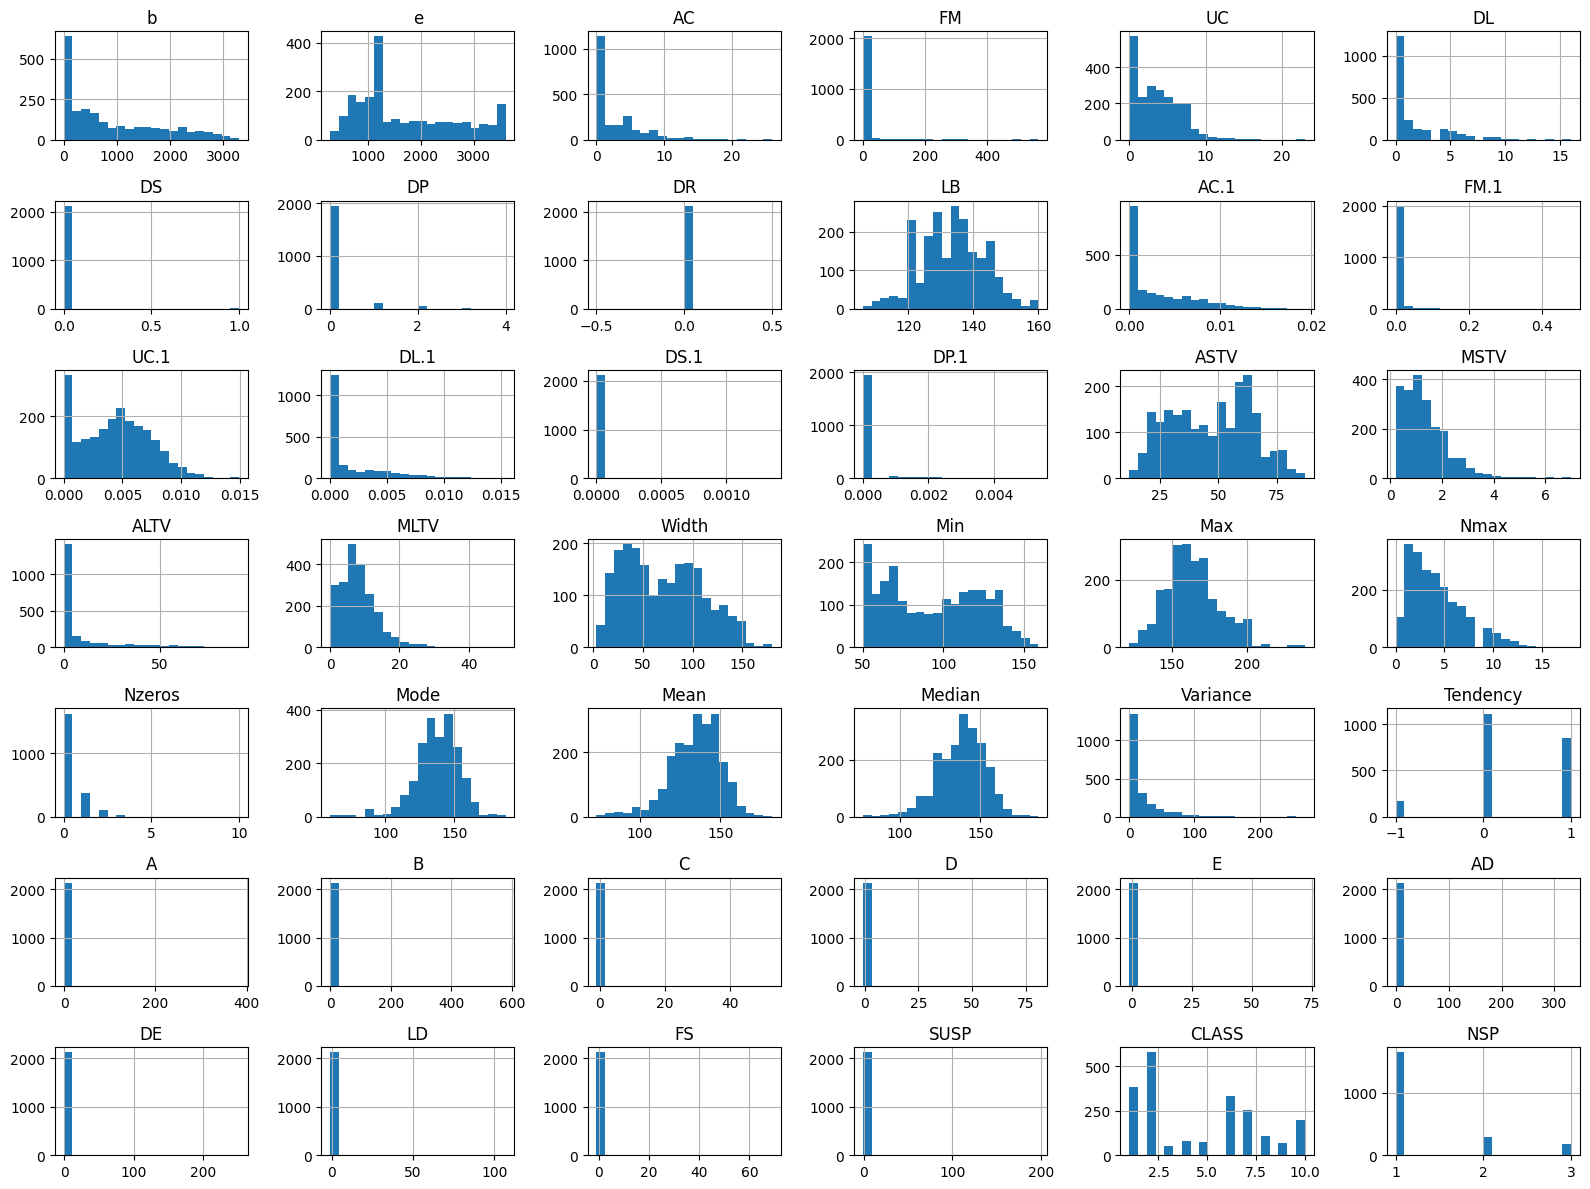

In [20]:
import matplotlib.pyplot as plt

df[num_cols].hist(figsize=(16, 12), bins=20)
plt.tight_layout()
plt.show()


<Figure size 1400x600 with 0 Axes>

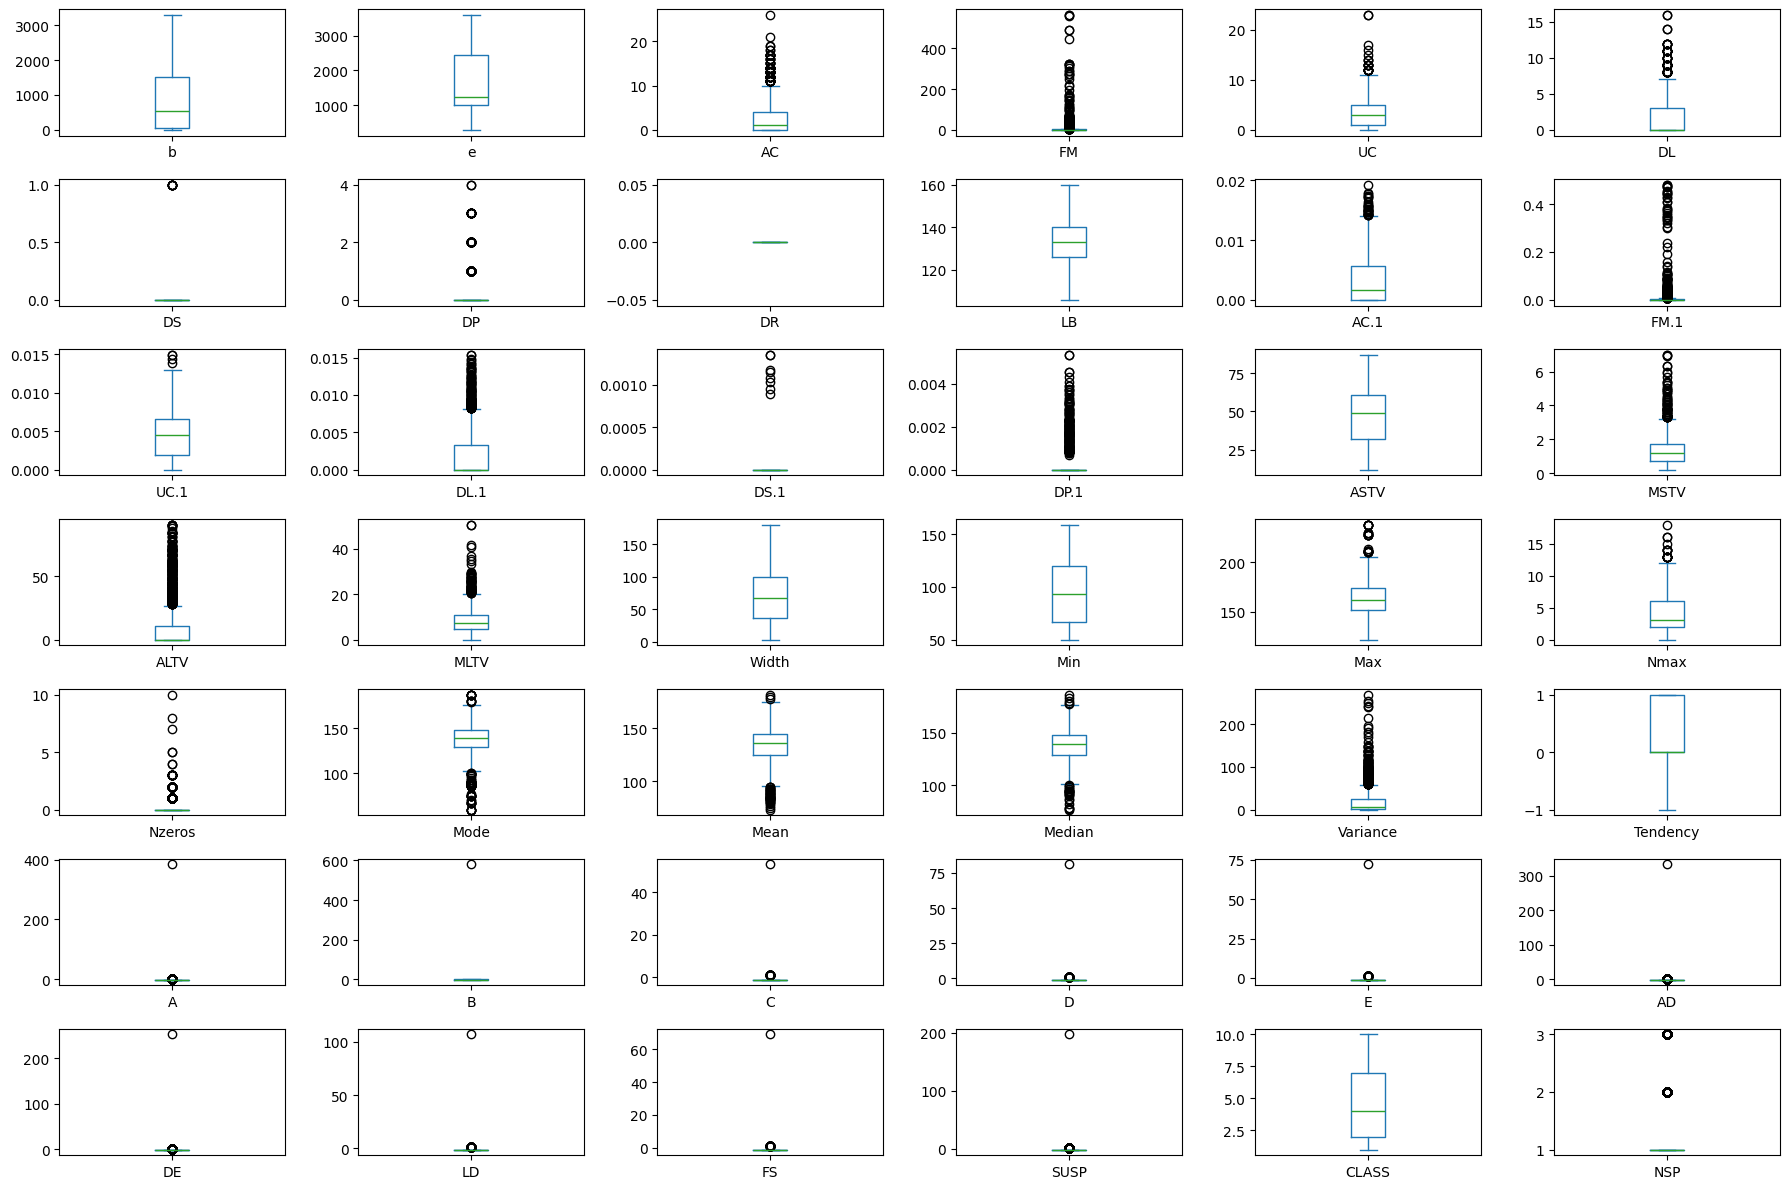

In [21]:
plt.figure(figsize=(14, 6))
df[num_cols].plot(kind="box", subplots=True, layout=(7, 6), figsize=(18, 12), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

### Analyse ciblée 

- Nous étudions en priorité la relation entre `LB` et `UC`, car ces deux variables décrivent respectivement la ligne de base du rythme cardiaque fœtal et les contractions utérines, c’est-à-dire les deux composantes centrales du CTG.
- Nous utilisons `NSP` comme variable cible, car elle correspond à une classification clinique en trois états : normal, suspect ou pathologique.

In [22]:
df_valid = df_valid[["LB", "UC", "NSP"]].copy()
df_valid.head()

,LB,UC,NSP
0,120.0,0.0,2.0
1,132.0,4.0,1.0
2,133.0,5.0,1.0
3,134.0,6.0,1.0
4,132.0,5.0,1.0


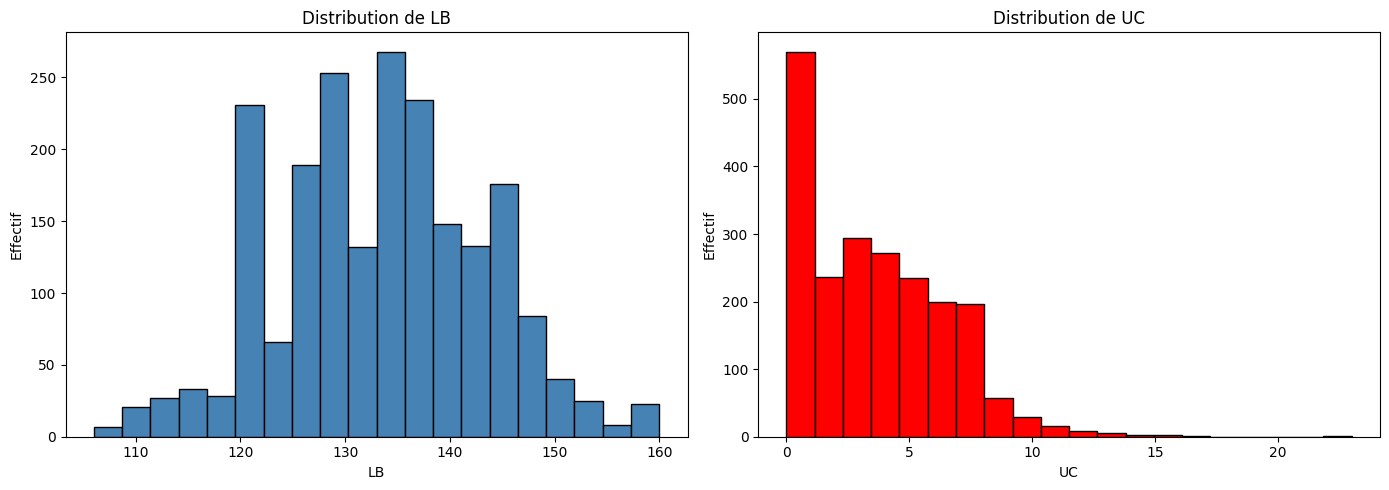

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df_valid["LB"], bins=20, color="steelblue", edgecolor="black")
plt.title("Distribution de LB")
plt.xlabel("LB")
plt.ylabel("Effectif")

plt.subplot(1, 2, 2)
plt.hist(df_valid["UC"], bins=20, color="red", edgecolor="black")
plt.title("Distribution de UC")
plt.xlabel("UC")
plt.ylabel("Effectif")

plt.tight_layout()
plt.show()


In [24]:
def find_outliers_IQR(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    IQR = q3 - q1
    outliers = col.loc[(col < (q1 - 1.5 * IQR)) | (col > (q3 + 1.5 * IQR))]
    return outliers

#Valeurs aberrantes pour la pression disatolique
outliers_UC = find_outliers_IQR(df_valid["UC"])

#Valeurs aberrantes pour la pression systolique
outliers_LB = find_outliers_IQR(df_valid["LB"])

print(outliers_UC)
print(outliers_LB)

561     12.0
792     17.0
793     13.0
794     12.0
1077    12.0
1290    13.0
1631    14.0
1632    15.0
1647    13.0
1679    14.0
1680    16.0
1732    12.0
1824    12.0
1934    12.0
1955    12.0
1956    13.0
1957    13.0
1958    14.0
1962    12.0
1963    13.0
2065    12.0
2086    23.0
Name: UC, dtype: float64
Series([], Name: LB, dtype: float64)


In [25]:
for feature in df_valid.columns:
    col = df_valid[feature]
    outliers = find_outliers_IQR(col)
    if len(outliers) > 0:
        print(f"{feature:10} {len(outliers)}")

outlier_indices_LB = find_outliers_IQR(df_valid["LB"]).index
outliers_LB = df_valid.loc[outlier_indices_LB]

outlier_indices_UC = find_outliers_IQR(df_valid["UC"]).index
outliers_UC = df_valid.loc[outlier_indices_UC]

outlier_indices_LB, outliers_LB
outlier_indices_UC, outliers_UC

# Union des outliers
outlier_indices = outlier_indices_LB.union(outlier_indices_UC)


UC         22
NSP        471


<Axes: >

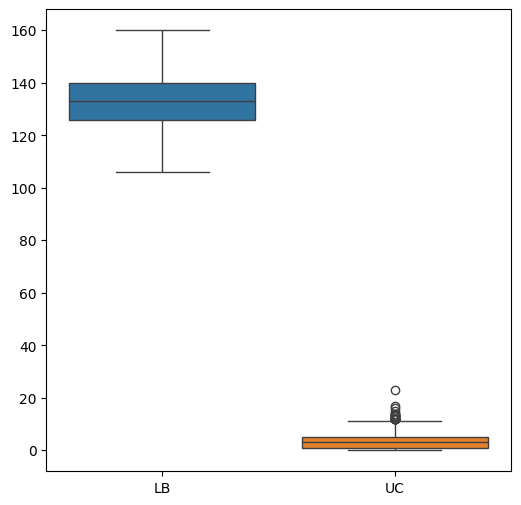

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (6,6))
sns.boxplot(df_valid.iloc[:,:-1])




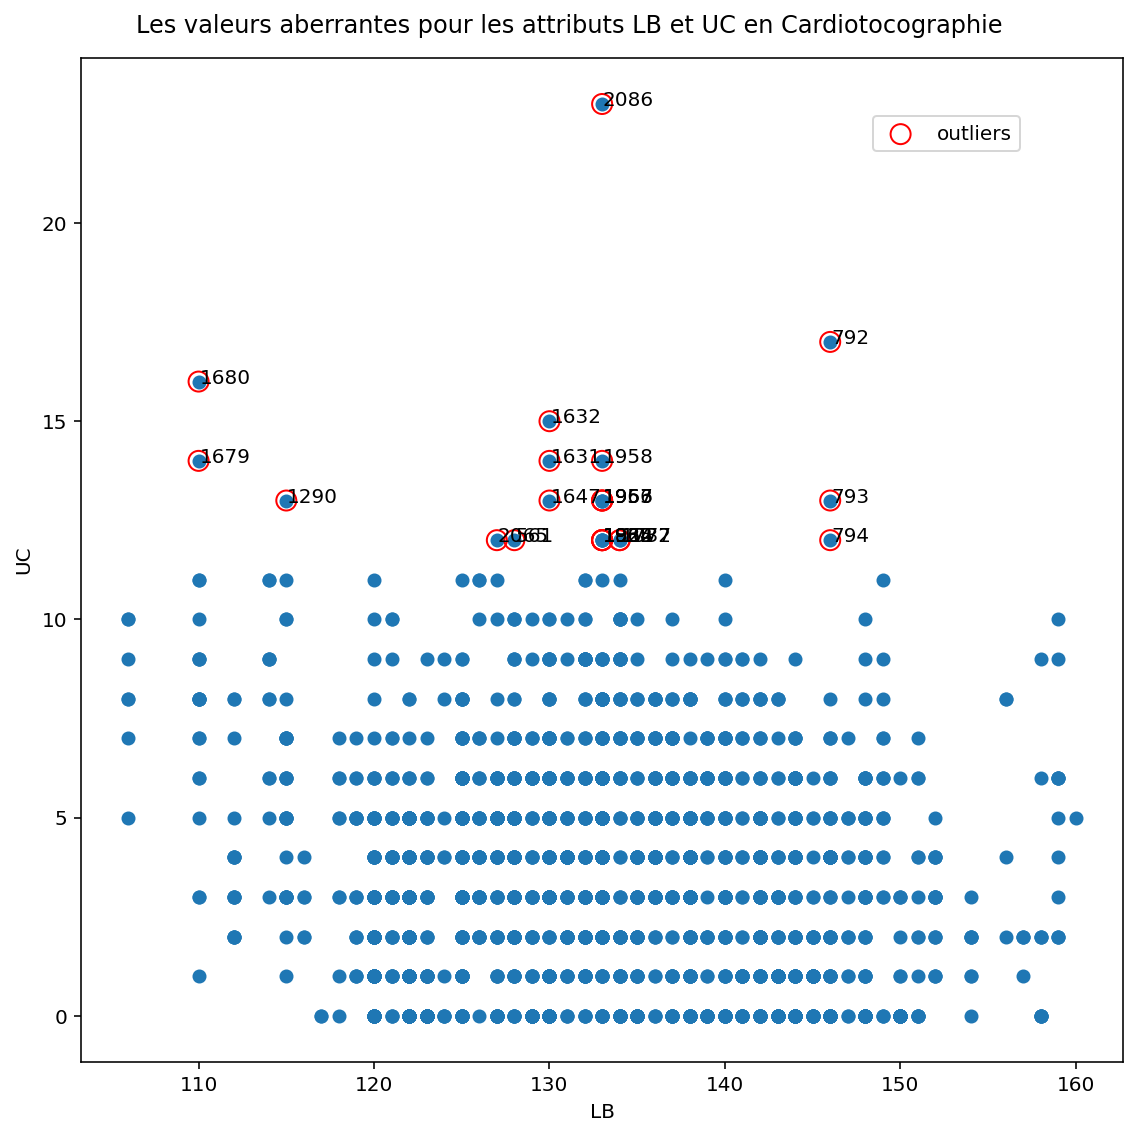

In [27]:
fig, ax = plt.subplots(figsize=(8,8), dpi=144)

ax.scatter(df_valid['LB'],df_valid['UC'])

for i in outlier_indices:
	outlier = df_valid.iloc[i]
	(x,y) = (outlier['LB'], outlier['UC'])
	ax.annotate(outlier.name, xy=(x+.05,y-.05))

ax.scatter(outliers_UC['LB'],outliers_UC['UC'],s=100,color='r',marker='o',facecolors='none', edgecolors='r', label='outliers')

ax.set_xlabel('LB')
ax.set_ylabel('UC')
fig.suptitle("Les valeurs aberrantes pour les attributs LB et UC en Cardiotocographie")
fig.legend(loc='upper right', bbox_to_anchor=(.9, .9))
fig.tight_layout()

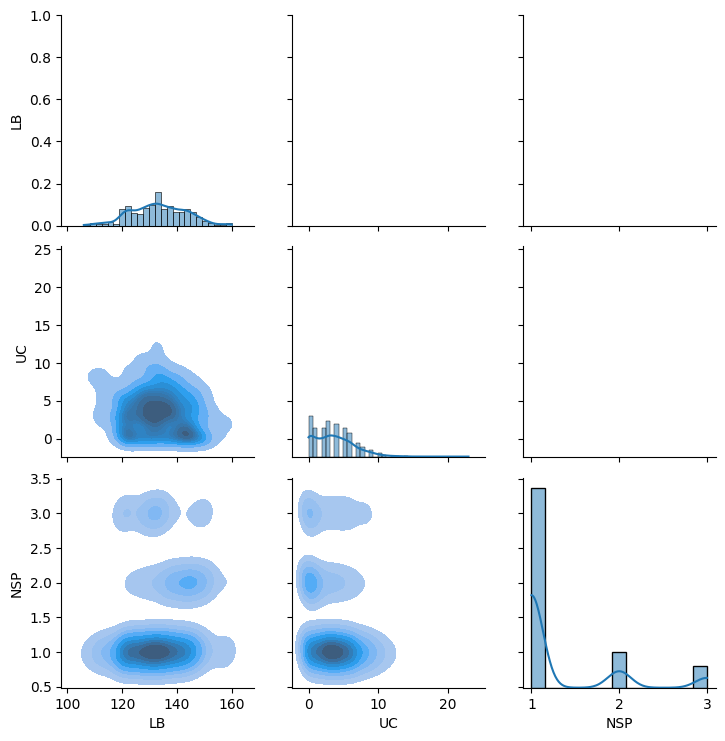

In [28]:
g = sns.PairGrid(df_valid)
#g.map_upper(sns.histplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, kde=True)

In [29]:
# NSP - (N=normal; S=suspect; P=pathologic)
df_valid["NSP"]

0       2.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
2121    2.0
2122    2.0
2123    2.0
2124    2.0
2125    1.0
Name: NSP, Length: 2126, dtype: float64

In [30]:
df_valid["NSP"].value_counts().sort_index()


NSP
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64

/var/folders/mc/k3xqw3fd25j6yk4f414tn1cm0000gn/T/ipykernel_95824/212783478.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="NSP", y="LB", ax=axes[0], palette="Set2")
/var/folders/mc/k3xqw3fd25j6yk4f414tn1cm0000gn/T/ipykernel_95824/212783478.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="NSP", y="UC", ax=axes[1], palette="Set2")


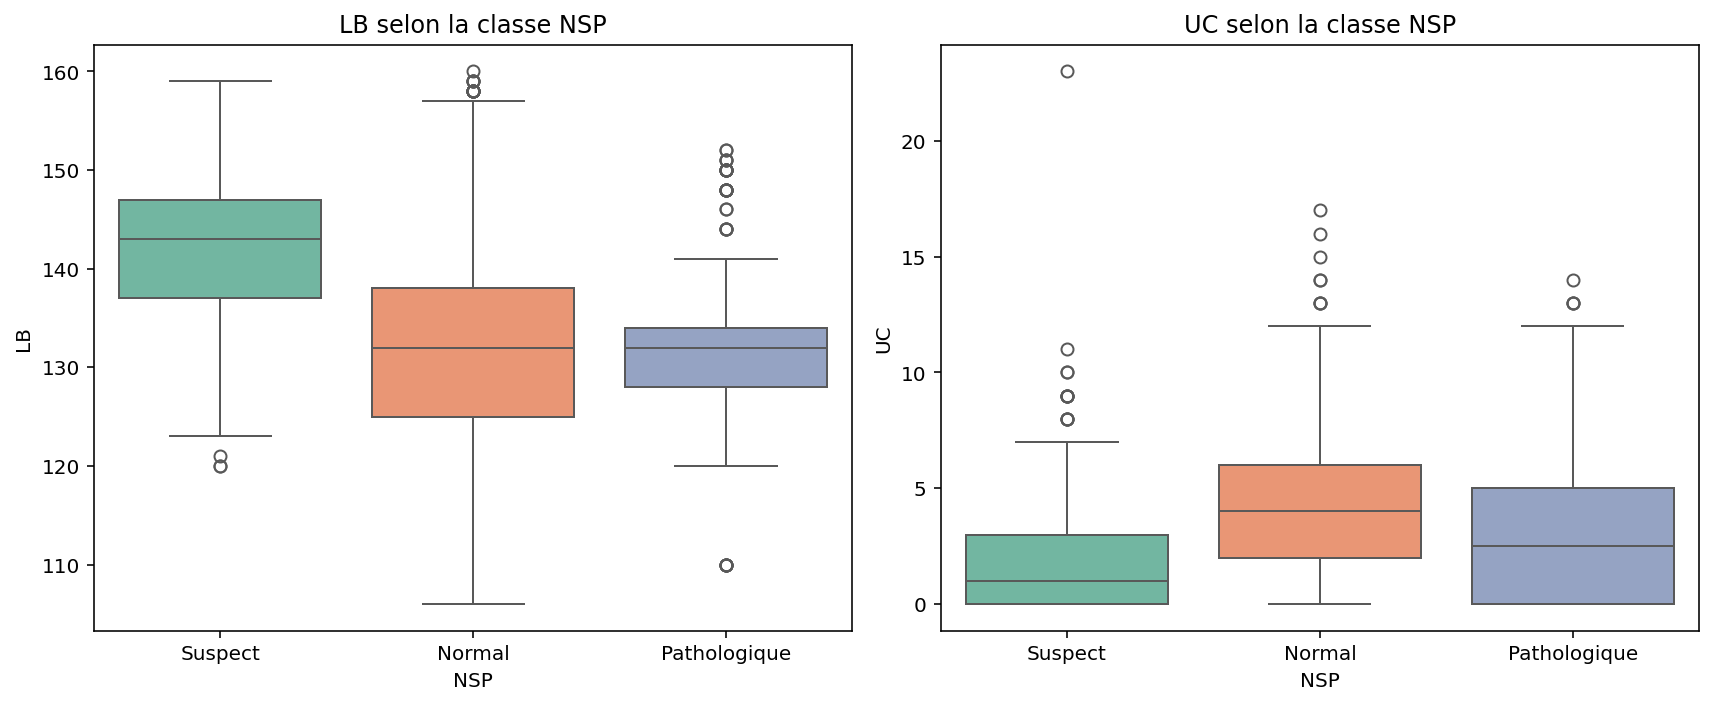

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_plot = df_valid.copy()
df_plot["NSP"] = df_plot["NSP"].map({1: "Normal", 2: "Suspect", 3: "Pathologique"})

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=144)

sns.boxplot(data=df_plot, x="NSP", y="LB", ax=axes[0], palette="Set2")
axes[0].set_title("LB selon la classe NSP")
axes[0].set_xlabel("NSP")
axes[0].set_ylabel("LB")

sns.boxplot(data=df_plot, x="NSP", y="UC", ax=axes[1], palette="Set2")
axes[1].set_title("UC selon la classe NSP")
axes[1].set_xlabel("NSP")
axes[1].set_ylabel("UC")

plt.tight_layout()
plt.show()



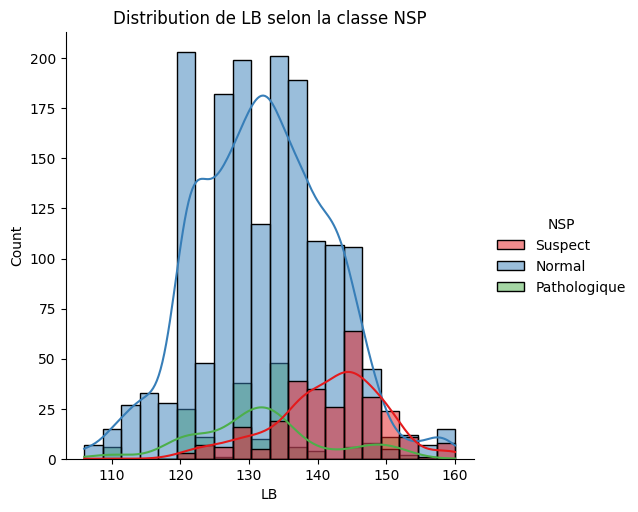

In [32]:
df_plot = df_valid.copy()
df_plot["NSP"] = df_plot["NSP"].map({1: "Normal", 2: "Suspect", 3: "Pathologique"})

sns.displot(
    data=df_plot,
    x="LB",
    hue="NSP",
    palette="Set1",
    kde=True,
    bins=20
)
plt.title("Distribution de LB selon la classe NSP")
plt.show()


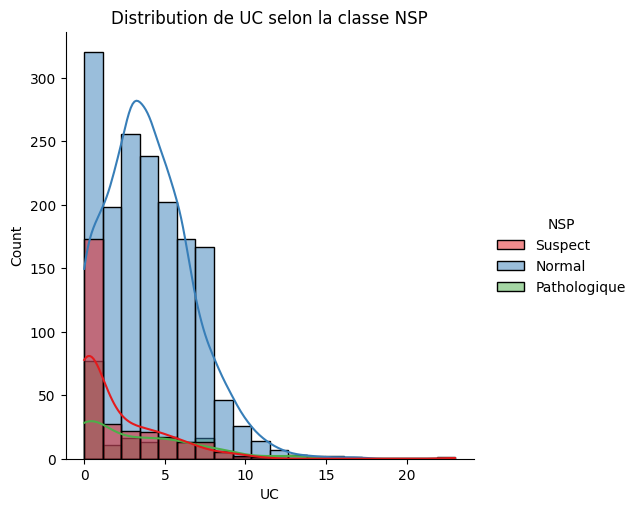

In [33]:
sns.displot(
    data=df_plot,
    x="UC",
    hue="NSP",
    palette="Set1",
    kde=True,
    bins=20
)
plt.title("Distribution de UC selon la classe NSP")
plt.show()

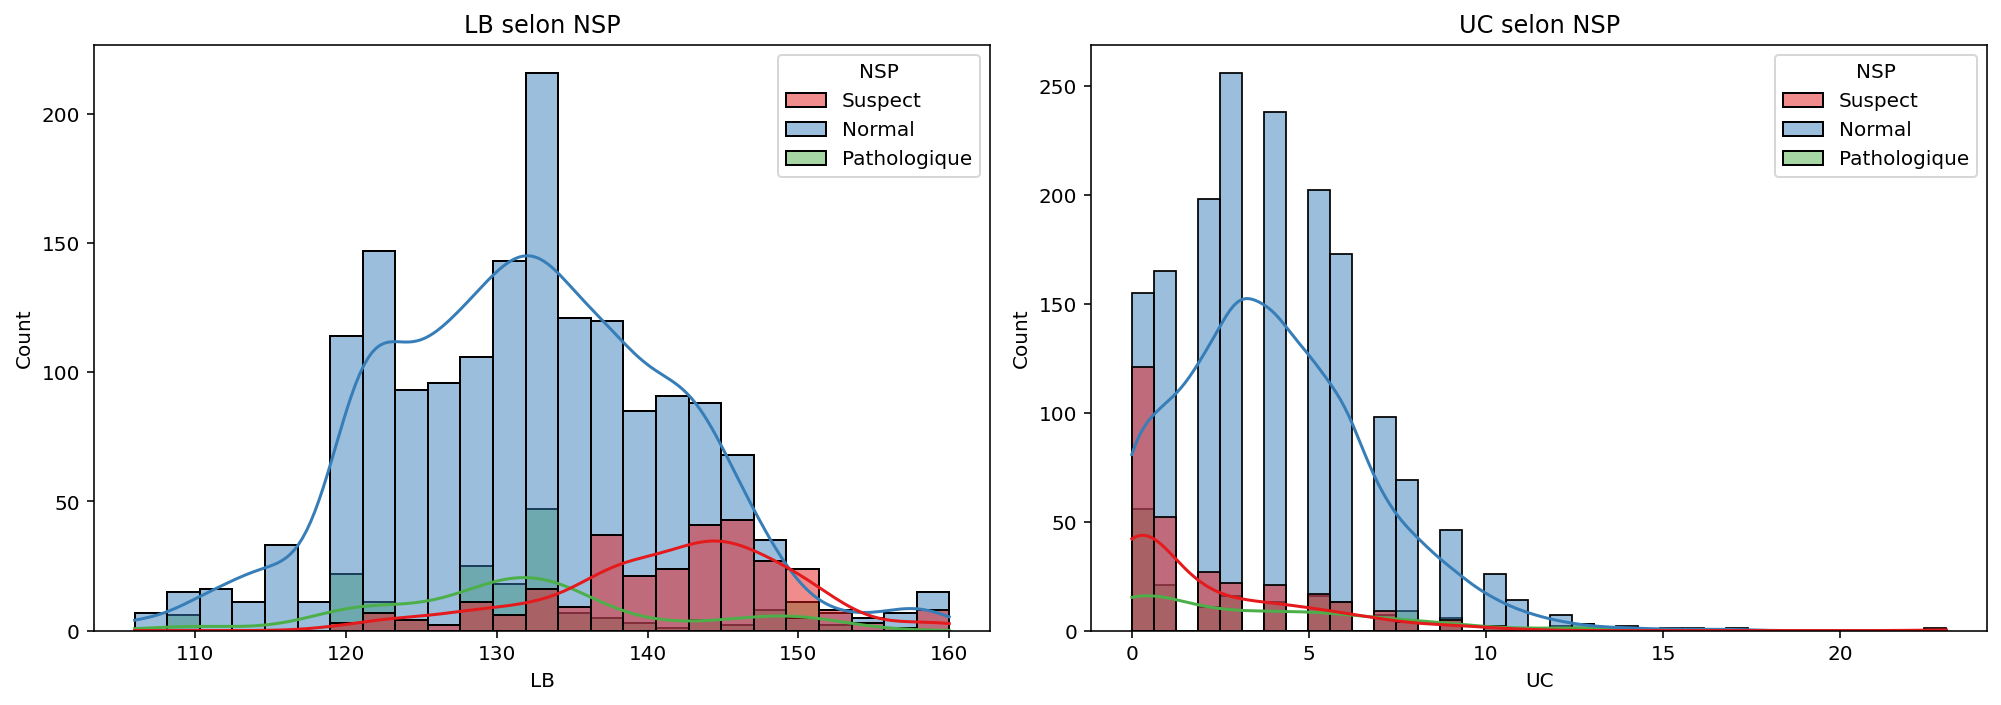

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_valid.copy()
df_plot["NSP"] = df_plot["NSP"].map({1: "Normal", 2: "Suspect", 3: "Pathologique"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=144)

sns.histplot(data=df_plot, x="LB", hue="NSP", kde=True, palette="Set1", ax=axes[0])
axes[0].set_title("LB selon NSP")

sns.histplot(data=df_plot, x="UC", hue="NSP", kde=True, palette="Set1", ax=axes[1])
axes[1].set_title("UC selon NSP")

plt.tight_layout()
plt.show()


### 2. Analyse des dépendances - multivariée

L'analyse multivariée a pour but d'étudier le lien entre plusieurs variables.

__Test de normalité__

In [35]:
print(df_valid)

         LB   UC  NSP
0     120.0  0.0  2.0
1     132.0  4.0  1.0
2     133.0  5.0  1.0
3     134.0  6.0  1.0
4     132.0  5.0  1.0
...     ...  ...  ...
2121  140.0  6.0  2.0
2122  140.0  9.0  2.0
2123  140.0  7.0  2.0
2124  140.0  9.0  2.0
2125  142.0  5.0  1.0

[2126 rows x 3 columns]


- Shapiro test :


In [36]:
import scipy.stats as st
UC = df_valid.loc[df_valid["UC"]]
LB = df_valid.loc[df_valid["LB"]]
NSP = df_valid.loc[df_valid["NSP"]]

In [37]:
shapiro_test_UC = st.shapiro(UC)
shapiro_test_LB = st.shapiro(LB)
shapiro_test_LB, shapiro_test_UC

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6378.
  res = hypotest_fun_out(*samples, **kwds)


(ShapiroResult(statistic=np.float64(0.6428731340187698), pvalue=np.float64(1.1090228071697342e-78)),
 ShapiroResult(statistic=np.float64(0.6430958572949824), pvalue=np.float64(1.1439332851574646e-78)))

p-value donne la probabilité qu'on observe une valeur inférieure à la valeur calculée de statistic. On rejette l'hypothèse de normalité.

In [38]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


- Q-Q plot :

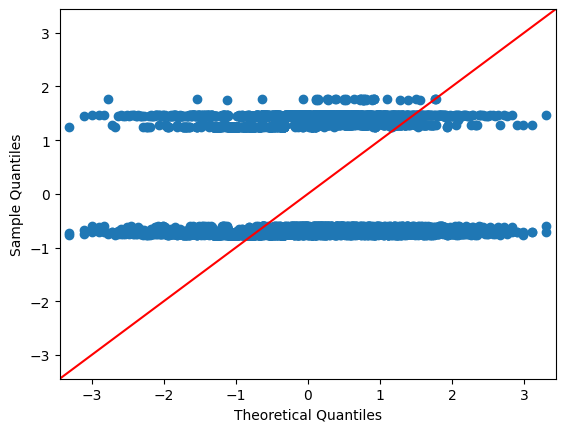

In [39]:
import statsmodels.api as sm 
fig = sm.qqplot(UC, fit=True, line='45')

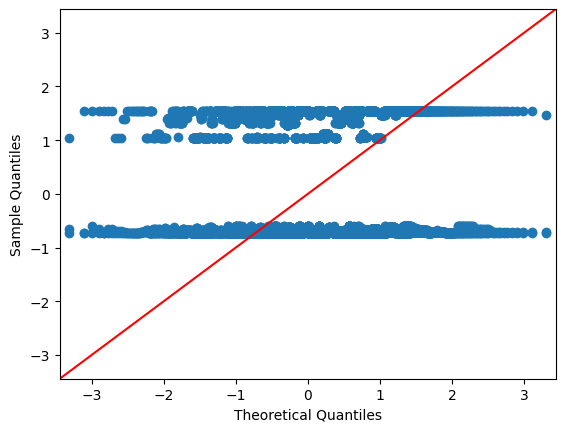

In [40]:
import statsmodels.api as sm 
fig = sm.qqplot(LB, fit=True, line='45')

### Lien entre deux variables numériques

__Corrélation__

Pour déterminer s'il y a une dépendance (linéaire) entre deux variables numériques, on peut calculer le coefficient de corrélation :

In [41]:
df_cible = df_valid[["LB", "UC", "NSP"]].copy()
corr = df_cible.iloc[:,:-1].corr()
corr

,LB,UC
LB,1.000000,-0.127722
UC,-0.127722,1.000000


et visualiser la matrice de corrélation :

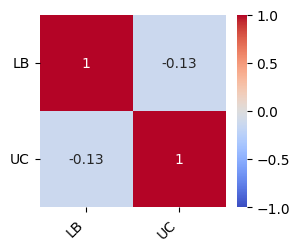

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
def correlation_heatmap(matrix):
    fig, ax = plt.subplots(figsize=(3,2.5))

    sns.heatmap(matrix, cmap='coolwarm', annot=True, vmin=-1, vmax=1)
    df_cible_marks = [i + .5 for i in range(len(matrix.columns))]
    plt.xticks(df_cible_marks, matrix.columns, rotation=45, ha='right')
    plt.yticks(df_cible_marks, matrix.index, rotation='horizontal')

correlation_heatmap(corr)

En enlevant la diagonale et symétrie :

In [43]:
import numpy as np

masked_corr = corr.copy()
mask = np.zeros_like(masked_corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
masked_corr[mask] = np.nan
masked_corr = masked_corr.iloc[1:,:-1]
masked_corr

,LB
UC,-0.127722


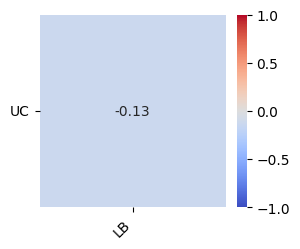

In [44]:
correlation_heatmap(masked_corr)

UC et LB ne sont pas corrélés, corr = - 0.13

__Test de corrélation Pearson__

Pour savoir si ces mesures sont statistiquement significatives sur le jeu de données, on fait un *test de corrélation Pearson*.

In [45]:
import scipy
scipy.stats.pearsonr(corr['UC'], y=corr['LB']).pvalue

np.float64(1.0)

In [46]:
p_corr = masked_corr.copy()
for (row, col) in zip(p_corr.index, p_corr.columns):
    p_corr.loc[row, col] = scipy.stats.pearsonr(corr[row], y=corr[col]).pvalue
p_corr

,LB
UC,1.0


p-value > 0.05 -> Pas de corrélation linéaire entre UC et LB.



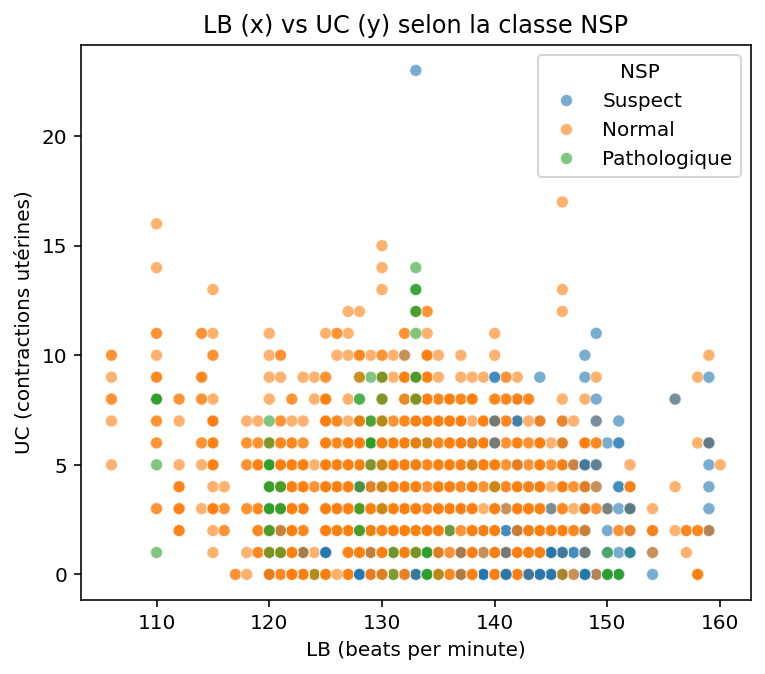

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_cible.copy()          # ou df si tu n'as pas dfvalid
df_plot["NSP"] = df_plot["NSP"].map({1: "Normal", 2: "Suspect", 3: "Pathologique"})

plt.figure(figsize=(6, 5), dpi=144)
sns.scatterplot(
    data=df_plot,
    x="LB",
    y="UC",
    hue="NSP",
    alpha=0.6
)
plt.title("LB (x) vs UC (y) selon la classe NSP")
plt.xlabel("LB (beats per minute)")
plt.ylabel("UC (contractions utérines)")
plt.legend(title="NSP")
plt.show()


La corrélation de Pearson entre LB et UC est faible (r ≈ −0,13) et non significative (p‑value > 0,05).
Le nuage de points LB en abscisse et UC en ordonnée ne montre pas de structure linéaire évidente, confirmant l’absence de corrélation linéaire statistiquement significative.

### Lien entre une variable numérique et une variable catégorielle

__Test de Kruskal-Wallis__

Étant donné que la distribution ne suit aucune loi de normalité, nous effecturons le test de Kruskal-Wallis (non-paramétrique)

In [48]:
from scipy import stats

df_kw = df_valid.copy()     
lb1 = df_kw.loc[df_kw["NSP"] == 1, "LB"]
lb2 = df_kw.loc[df_kw["NSP"] == 2, "LB"]
lb3 = df_kw.loc[df_kw["NSP"] == 3, "LB"]

uc1 = df_kw.loc[df_kw["NSP"] == 1, "UC"]
uc2 = df_kw.loc[df_kw["NSP"] == 2, "UC"]
uc3 = df_kw.loc[df_kw["NSP"] == 3, "UC"]

kw_lb = stats.kruskal(lb1, lb2, lb3)
kw_uc = stats.kruskal(uc1, uc2, uc3)

print("Kruskal-Wallis LB ~ NSP :", kw_lb)
print("Kruskal-Wallis UC ~ NSP :", kw_uc)

Kruskal-Wallis LB ~ NSP : KruskalResult(statistic=np.float64(254.33367250544305), pvalue=np.float64(5.917588127255909e-56))
Kruskal-Wallis UC ~ NSP : KruskalResult(statistic=np.float64(157.71242363560964), pvalue=np.float64(5.6647708129373e-35))


p < 0,05 :
Le test de Kruskal‑Wallis montre une différence significative de la distribution de LB (ou UC) selon les classes NSP, ce qui suggère une dépendance entre LB (ou UC) et l’état foetal.

In [49]:
!pip install scikit-posthocs

__Test de Dunn__

In [50]:
import scikit_posthocs as sp

# Dunn pour LB
dunn_lb = sp.posthoc_dunn(
    df_kw,                 # dataframe complet
    val_col="LB",          # variable numérique
    group_col="NSP",       # groupe
    p_adjust="bonferroni"  # ou "holm"
)
print("Dunn (LB ~ NSP) :")
print(dunn_lb)

# Dunn pour UC
dunn_uc = sp.posthoc_dunn(
    df_kw,
    val_col="UC",
    group_col="NSP",
    p_adjust="bonferroni"
)
print("Dunn (UC ~ NSP) :")
print(dunn_uc)

Dunn (LB ~ NSP) :
              1.0           2.0           3.0
1.0  1.000000e+00  2.057198e-55  1.000000e+00
2.0  2.057198e-55  1.000000e+00  2.260698e-27
3.0  1.000000e+00  2.260698e-27  1.000000e+00
Dunn (UC ~ NSP) :
              1.0           2.0       3.0
1.0  1.000000e+00  1.189418e-33  0.000020
2.0  1.189418e-33  1.000000e+00  0.000044
3.0  1.989122e-05  4.438677e-05  1.000000


Méthode Bonfferoni du test de Dunn : permet d’être prudent sur les faux-positifs et donc d’ajuster la p-value pour que le taux d’erreur global sur l’ensemble des comparaisons reste ≈ 5%.

- Le test de Dunn (corrigé de Bonferroni) montre que la distribution de LB diffère significativement entre les classes NSP = 1 et 2, ainsi qu’entre NSP = 2 et 3 (p‑values ajustées < 0,001), tandis qu’aucune différence significative n’est observée entre NSP = 1 et 3 (p‑value ajustée = 1). Cela suggère que les tracés suspects (NSP = 2) se distinguent nettement des tracés normaux et pathologiques en termes de ligne de base.

- Pour UC, le test de Dunn met en évidence des différences significatives entre toutes les paires de classes NSP (1–2, 1–3 et 2–3, p‑values ajustées < 0,001). Les contractions utérines diffèrent donc nettement entre les trois états foetaux (normal, suspect, pathologique).

__Information mutuelle__

In [51]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# X = variables explicatives (numériques)
X = df_valid[["LB", "UC"]]   
y = df_valid["NSP"]  # cible catégorielle

mi = mutual_info_classif(X, y, discrete_features=False, random_state=0)

mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(mi_series)

LB    0.127525
UC    0.059715
dtype: float64


L’information mutuelle entre NSP et LB (MI ≈ 0,13) est plus élevée qu’entre NSP et UC (MI ≈ 0,06), nous indiquant que LB apporte davantage d’information sur la classe NSP qu’UC, même si ces dépendances restent globalement faibles. Ces résultats confirment que LB est un meilleur candidat que UC pour discriminer les états foetaux, ce qui est cohérent avec nos tests de corrélation et de Kruskal‑Wallis.